Name: David Zhang

SJSU ID: 015801357

GitHub link: https://github.com/dqvidzhang

In [3]:
# Basic python libraries - numeric calculations, dataframes, and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The dataset for this activity
from sklearn.datasets import load_iris

# The ML libraries
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

# ML Methodology
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
iris   = load_iris()
X_iris = iris.data
y_iris = iris.target

TODO: Explore the shapes of X_iris and y_iris

In [5]:
# Put it in a dataframe
df_iris = pd.DataFrame(X_iris, columns=iris.feature_names)
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
df_iris['species'] = [iris.target_names[t] for t in y_iris]

In [9]:
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Pick any two features and plot them against each other

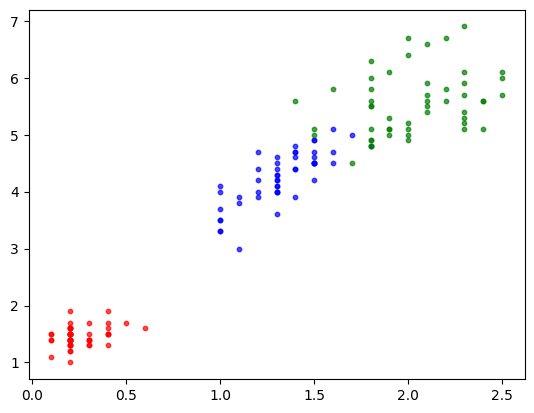

In [19]:
features = iris.feature_names
colors   = {'setosa': 'red', 'versicolor': 'blue', 'virginica': 'green'}

feat1 = features[3]
feat2 = features[2]

for species, color in colors.items():
  mask = df_iris['species'] == species
  plt.scatter(df_iris.loc[mask, feat1],
              df_iris.loc[mask, feat2],
              c=color, s=10, alpha=0.7)

The textbook full plot is below:

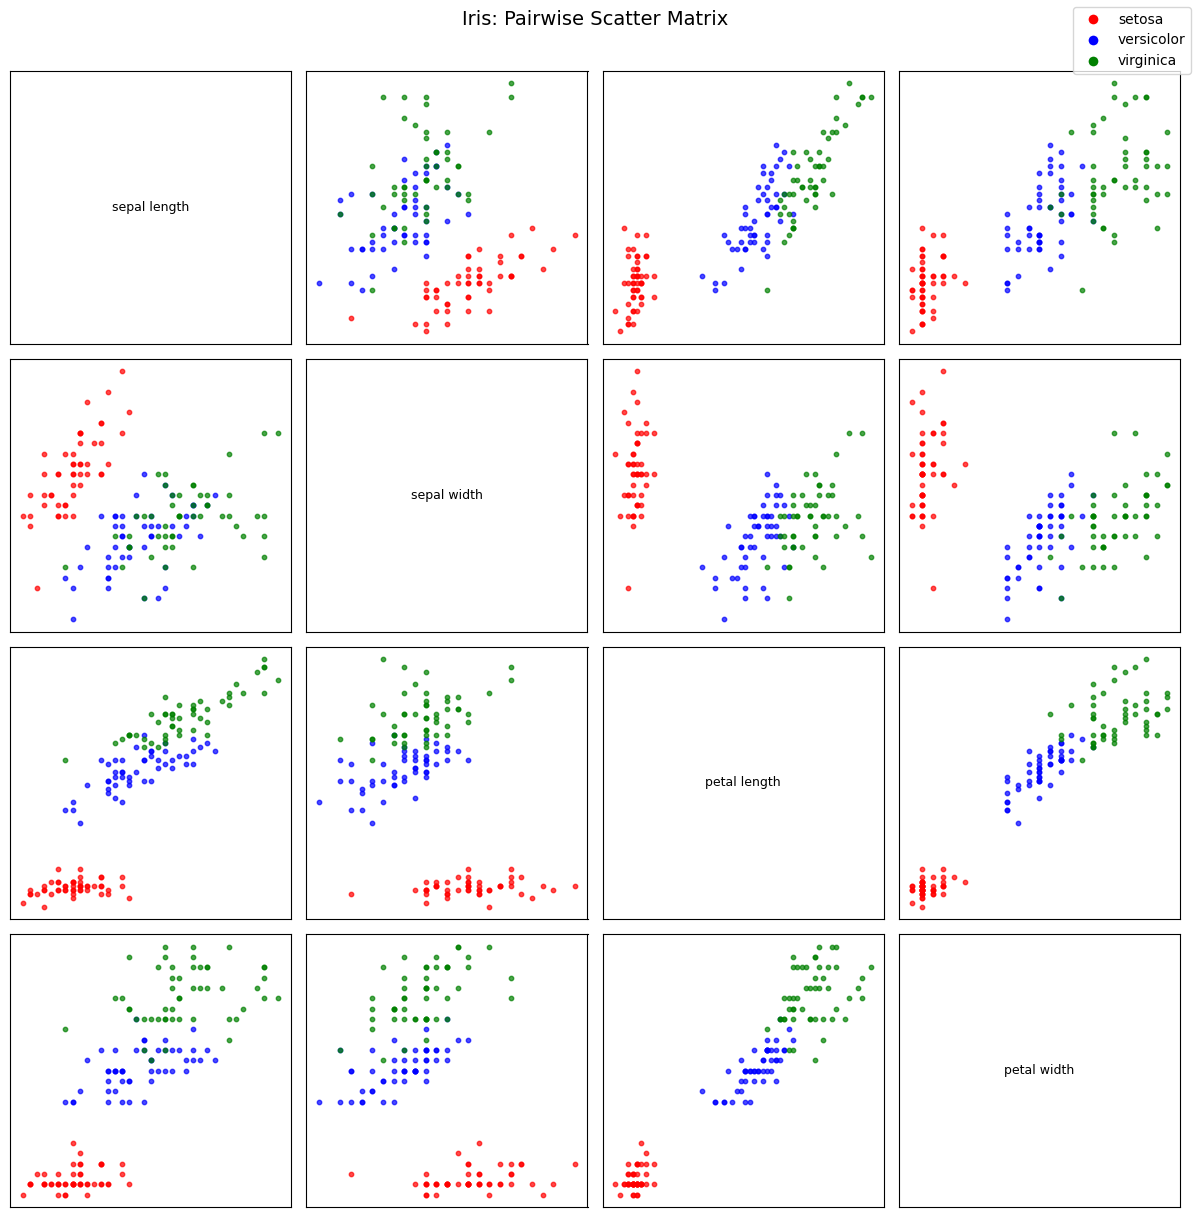

In [20]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for i, feat_i in enumerate(features):
    for j, feat_j in enumerate(features):
        ax = axes[i][j]
        if i == j:
            ax.text(0.5, 0.5, feat_i.replace(' (cm)', ''),
                    ha='center', va='center', fontsize=9, wrap=True)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            for species, color in colors.items():
                mask = df_iris['species'] == species
                ax.scatter(df_iris.loc[mask, feat_j],
                           df_iris.loc[mask, feat_i],
                           c=color, s=10, alpha=0.7)
            ax.set_xticks([])
            ax.set_yticks([])

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=c, markersize=8, label=s)
           for s, c in colors.items()]
fig.legend(handles=handles, loc='upper right', fontsize=10)
fig.suptitle('Iris: Pairwise Scatter Matrix', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Let's do Machine Learning on this data now

Difference between *Supervised*, *Unsupervised*, and *Self-supervised* learning

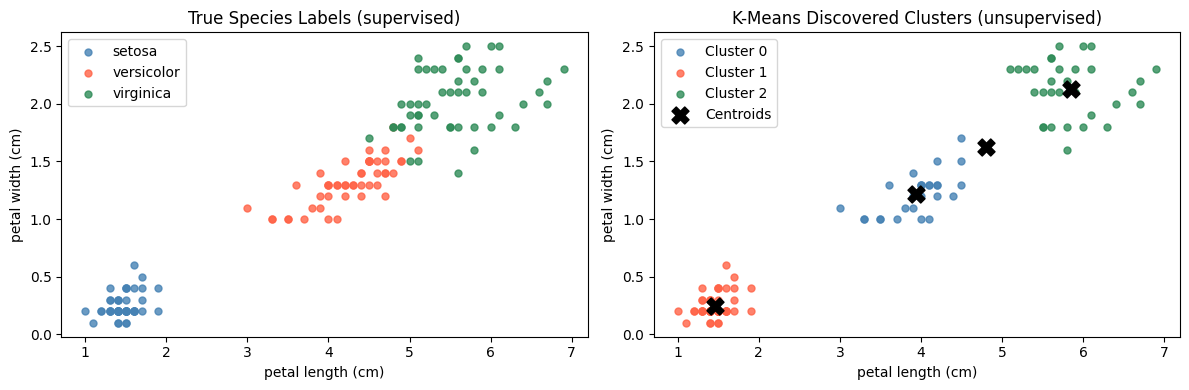

In [33]:
# K-Means on Iris — no labels used during fitting
kmeans = KMeans(n_clusters=4, n_init=7)
cluster_labels = kmeans.fit_predict(X_iris)

# Visualize on petal length vs. petal width (the most separable pair)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: true species labels
for species, color, idx in zip(iris.target_names,
                                ['steelblue', 'tomato', 'seagreen'],
                                [0, 1, 2]):
    mask = y_iris == idx
    axes[0].scatter(X_iris[mask, 2], X_iris[mask, 3],
                    c=color, s=25, alpha=0.8, label=species)
axes[0].set_xlabel('petal length (cm)')
axes[0].set_ylabel('petal width (cm)')
axes[0].set_title('True Species Labels (supervised)')
axes[0].legend()

# Right: k-means clusters (no labels used)
cluster_colors = ['steelblue', 'tomato', 'seagreen']
for k in range(3):
    mask = cluster_labels == k
    axes[1].scatter(X_iris[mask, 2], X_iris[mask, 3],
                    c=cluster_colors[k], s=25, alpha=0.8, label=f'Cluster {k}')
axes[1].scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3],
                c='black', marker='X', s=150, zorder=5, label='Centroids')
axes[1].set_xlabel('petal length (cm)')
axes[1].set_ylabel('petal width (cm)')
axes[1].set_title('K-Means Discovered Clusters (unsupervised)')
axes[1].legend()

plt.tight_layout()
plt.show()

Generalization

In [31]:
# Train/test split for Iris — 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2
)

# Fit logistic regression
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

iris_lr_ein  = 1 - accuracy_score(y_train, clf.predict(X_train))
iris_lr_eout = 1 - accuracy_score(y_test,  clf.predict(X_test))

print(f'Logistic Regression on Iris:')
print(f'  E_in  (120 training samples) = {iris_lr_ein:.3f}')
print(f'  E_out  (30 test samples)     = {iris_lr_eout:.3f}')
print(f'  Generalization gap            = {iris_lr_eout - iris_lr_ein:.3f}')

Logistic Regression on Iris:
  E_in  (120 training samples) = 0.017
  E_out  (30 test samples)     = 0.033
  Generalization gap            = 0.017


For supervised learning, I would use the Iris flower measurements as the inputs and the known species as the labels.

For unsupervised learning, I would remove the species labels and use K-Means clustering to group flowers based only on their measurements.

For self-supervised learning, I could hide one of the flower measurements, such as petal width, and train the model to predict it using the other measurements.


When I changed the number of clusters in K-Means, the data was divided into more groups and more cluster centers appeared on the graph. With three clusters, the groups match the three Iris species. Increasing the number of clusters creates smaller groups within the data, even though there are still only three actual species.


A high generalization gap means the model performs well on the training data but performs worse on unseen test data.
